Tổng quan bộ dữ liệu
Gồm 2 file:

winequality-red.csv: 1599 mẫu rượu vang đỏ

winequality-white.csv: 4898 mẫu rượu vang trắng

Mỗi dòng là 1 mẫu rượu với:

11 đặc trưng hóa học

1 nhãn đầu ra: quality (chất lượng)

1) Đọc dữ liệu 

In [68]:
import pandas as pd

# Red wine
df_red = pd.read_csv("D:\LAP TRINH\DS108.O21.2\LAB_4\wine+quality\winequality-red.csv", sep=";")

# White wine
df_white = pd.read_csv("D:\LAP TRINH\DS108.O21.2\LAB_4\wine+quality\winequality-white.csv", sep=";")

<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:7: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:7: SyntaxWarning: invalid escape sequence '\L'
C:\Users\Thy\AppData\Local\Temp\ipykernel_2460\2254285569.py:4: SyntaxWarning: invalid escape sequence '\L'
  df_red = pd.read_csv("D:\LAP TRINH\DS108.O21.2\LAB_4\wine+quality\winequality-red.csv", sep=";")
C:\Users\Thy\AppData\Local\Temp\ipykernel_2460\2254285569.py:7: SyntaxWarning: invalid escape sequence '\L'
  df_white = pd.read_csv("D:\LAP TRINH\DS108.O21.2\LAB_4\wine+quality\winequality-white.csv", sep=";")


In [69]:
df_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [70]:
df_white

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


**RED WINE**

2) Thống kê số lượng nhãn, số lượng thuộc tính và phân bố dữ liệu theo nhãn.

In [71]:
label_col = 'quality'  # Cột nhãn
num_samples = df_red.shape[0]  # Số lượng mẫu
num_features = df_red.shape[1] - 1  # Trừ cột nhãn
num_classes = df_red[label_col].nunique()
label_distribution = df_red[label_col].value_counts()

num_features, num_classes, label_distribution

(11,
 6,
 quality
 5    681
 6    638
 7    199
 4     53
 8     18
 3     10
 Name: count, dtype: int64)

3) Chuẩn bị dữ liệu: phân chia dữ liệu ban đầu thành 2 tập: huấn luyện (train) và kiểm thử (test) với tỉ lệ 8-2.

In [72]:
from sklearn.model_selection import train_test_split
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
from sklearn.preprocessing import StandardScaler

In [73]:
X = df_red.drop(label_col, axis=1)
y = df_red[label_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4) Cài đặt mô hình: kNN và SVM. Sử dụng kỹ thuật cross validation.
5) Đánh giá mô hình: Độ chính xác (Accuracy) Ma trận nhầm lẫn (Confusion matrix)

[CV] kNN Accuracy trung bình (cv=5): 0.4965
[CV] SVM Accuracy trung bình (cv=5): 0.5020
[Test] kNN Accuracy: 0.4562
[Test] SVM Accuracy: 0.5094
Confusion Matrix - kNN:


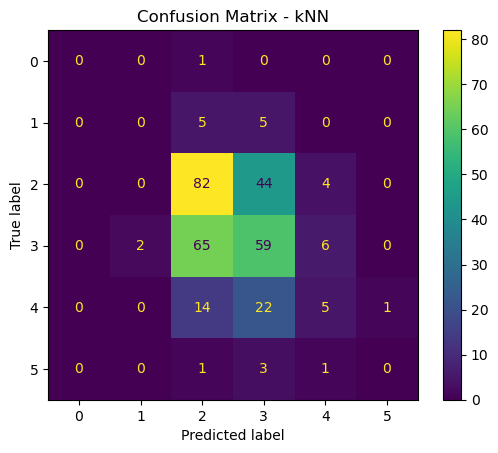

c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.49      0.63      0.55       130
           6       0.44      0.45      0.45       132
           7       0.31      0.12      0.17        42
           8       0.00      0.00      0.00         5

    accuracy                           0.46       320
   macro avg       0.21      0.20      0.19       320
weighted avg       0.42      0.46      0.43       320

Confusion Matrix - SVM:


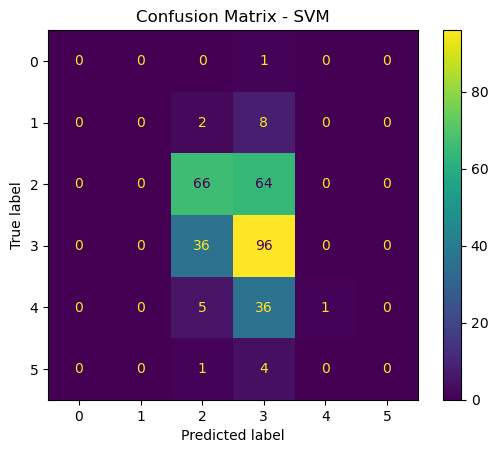

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.60      0.51      0.55       130
           6       0.46      0.73      0.56       132
           7       1.00      0.02      0.05        42
           8       0.00      0.00      0.00         5

    accuracy                           0.51       320
   macro avg       0.34      0.21      0.19       320
weighted avg       0.56      0.51      0.46       320



c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# --- Khởi tạo mô hình ---
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1, gamma='scale')

cv = 5  # Số lượng folds

# --- Cross-validation ---
knn_cv_scores = cross_val_score(knn, X_train, y_train, cv=cv)
svm_cv_scores = cross_val_score(svm, X_train, y_train, cv=cv)

print(f"[CV] kNN Accuracy trung bình (cv={cv}): {knn_cv_scores.mean():.4f}")
print(f"[CV] SVM Accuracy trung bình (cv={cv}): {svm_cv_scores.mean():.4f}")

# --- Huấn luyện mô hình với toàn bộ tập train ---
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

# --- Dự đoán ---
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)

# --- Độ chính xác trên tập test ---
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"[Test] kNN Accuracy: {acc_knn:.4f}")
print(f"[Test] SVM Accuracy: {acc_svm:.4f}")

# --- Ma trận nhầm lẫn ---
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)

print("Confusion Matrix - kNN:")
disp_knn.plot()
plt.title("Confusion Matrix - kNN")
plt.show()
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix - SVM:")
disp_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()
print(classification_report(y_test, y_pred_svm))

7) Cài đặt thêm 2 thuật toán: Linear Discriminant Analysis (LDA) và Random Forest (RF). So sánh kết quả giữa 4 mô hình với nhau.

In [75]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

In [76]:
lda = LinearDiscriminantAnalysis()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [77]:
# LDA
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

# RF
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [78]:
print("Confusion Matrix - LDA:")
print(confusion_matrix(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

Confusion Matrix - LDA:
[[ 0  0  1  0  0  0]
 [ 2  0  6  2  0  0]
 [ 0  0 96 31  3  0]
 [ 1  0 45 70 16  0]
 [ 0  0  3 26 13  0]
 [ 0  0  0  1  4  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.64      0.74      0.68       130
           6       0.54      0.53      0.53       132
           7       0.36      0.31      0.33        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.26      0.26      0.26       320
weighted avg       0.53      0.56      0.54       320



c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [79]:
print("Confusion Matrix - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Confusion Matrix - Random Forest:
[[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 98 31  1  0]
 [ 0  1 31 91  8  1]
 [ 0  0  0 19 22  1]
 [ 0  0  0  1  4  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


8)* Thực hiện lại các bước từ 1 tới 7 khoảng 5 lần, ứng với mỗi lần thực hiện ghi lại giá trị Accuracy và thay đổi giá trị seed. Sau đó tính và ghi ra kết quả Accuracy trung bình của 5 lần thực hiện.

In [80]:
import numpy as np

# Danh sách để lưu Accuracy
knn_accuracies = []
svm_accuracies = []
lda_accuracies = []
rf_accuracies = []

# Thực hiện 5 lần với các seed khác nhau
for seed in [42, 7, 123, 2023, 99]:
    # Bước 1-2: Chia dữ liệu (giữ nguyên X, y từ preprocessing trước đó)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Bước 3: Tạo mô hình
    knn = KNeighborsClassifier(n_neighbors=3)
    svm = SVC(kernel='linear')
    lda = LinearDiscriminantAnalysis()
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)

    # Bước 4: Huấn luyện mô hình
    knn.fit(X_train, y_train)
    svm.fit(X_train, y_train)
    lda.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    # Bước 5: Dự đoán
    y_pred_knn = knn.predict(X_test)
    y_pred_svm = svm.predict(X_test)
    y_pred_lda = lda.predict(X_test)
    y_pred_rf = rf.predict(X_test)

    # Bước 6: Accuracy
    acc_knn = accuracy_score(y_test, y_pred_knn)
    acc_svm = accuracy_score(y_test, y_pred_svm)
    acc_lda = accuracy_score(y_test, y_pred_lda)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    # Lưu lại kết quả
    knn_accuracies.append(acc_knn)
    svm_accuracies.append(acc_svm)
    lda_accuracies.append(acc_lda)
    rf_accuracies.append(acc_rf)

    # In kết quả từng lần
    print(f"Seed {seed} - kNN Accuracy: {acc_knn:.4f} | SVM Accuracy: {acc_svm:.4f} | LDA Accuracy: {acc_lda:.4f} | RF Accuracy: {acc_rf:.4f}")

# Bước 7: Tính độ chính xác trung bình
avg_knn = np.mean(knn_accuracies)
avg_svm = np.mean(svm_accuracies)
avg_lda = np.mean(lda_accuracies)
avg_rf = np.mean(rf_accuracies)

print("\n==============================")
print(f"Trung bình Accuracy kNN: {avg_knn:.4f}")
print(f"Trung bình Accuracy SVM: {avg_svm:.4f}")
print(f"Trung bình Accuracy LDA: {avg_lda:.4f}")
print(f"Trung bình Accuracy RF: {avg_rf:.4f}")


Seed 42 - kNN Accuracy: 0.4531 | SVM Accuracy: 0.5687 | LDA Accuracy: 0.5594 | RF Accuracy: 0.6594
Seed 7 - kNN Accuracy: 0.5219 | SVM Accuracy: 0.6000 | LDA Accuracy: 0.5969 | RF Accuracy: 0.7000
Seed 123 - kNN Accuracy: 0.4906 | SVM Accuracy: 0.5281 | LDA Accuracy: 0.5500 | RF Accuracy: 0.6594
Seed 2023 - kNN Accuracy: 0.4875 | SVM Accuracy: 0.5469 | LDA Accuracy: 0.5687 | RF Accuracy: 0.6438
Seed 99 - kNN Accuracy: 0.5156 | SVM Accuracy: 0.6062 | LDA Accuracy: 0.5781 | RF Accuracy: 0.6687

Trung bình Accuracy kNN: 0.4938
Trung bình Accuracy SVM: 0.5700
Trung bình Accuracy LDA: 0.5706
Trung bình Accuracy RF: 0.6663


**WHITE WINE**


2) Thống kê số lượng nhãn, số lượng thuộc tính và phân bố dữ liệu theo nhãn.

In [81]:
label_col = 'quality'  # Cột nhãn
num_samples = df_white.shape[0]  # Số lượng mẫu
num_features = df_white.shape[1] - 1  # Trừ cột nhãn
num_classes = df_white[label_col].nunique()
label_distribution = df_white[label_col].value_counts()

num_features, num_classes, label_distribution

(11,
 7,
 quality
 6    2198
 5    1457
 7     880
 8     175
 4     163
 3      20
 9       5
 Name: count, dtype: int64)

3) Chuẩn bị dữ liệu: phân chia dữ liệu ban đầu thành 2 tập: huấn luyện (train) và kiểm thử (test) với tỉ lệ 8-2.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [83]:
X = df_white.drop(label_col, axis=1)
y = df_white[label_col]   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4) Cài đặt mô hình: kNN và SVM. Sử dụng kỹ thuật cross validation.
5) Đánh giá mô hình: Độ chính xác (Accuracy) Ma trận nhầm lẫn (Confusion matrix).

[CV] kNN Accuracy trung bình (cv=5): 0.4681
[CV] SVM Accuracy trung bình (cv=5): 0.4507
[Test] kNN Accuracy: 0.4827
[Test] SVM Accuracy: 0.4429
Confusion Matrix - kNN:


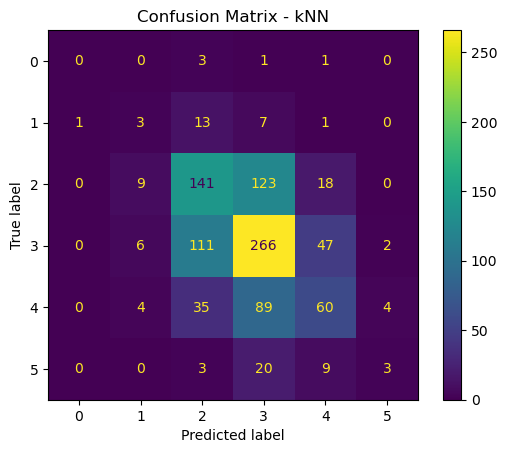

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.14      0.12      0.13        25
           5       0.46      0.48      0.47       291
           6       0.53      0.62      0.57       432
           7       0.44      0.31      0.37       192
           8       0.33      0.09      0.14        35

    accuracy                           0.48       980
   macro avg       0.32      0.27      0.28       980
weighted avg       0.47      0.48      0.47       980

Confusion Matrix - SVM:


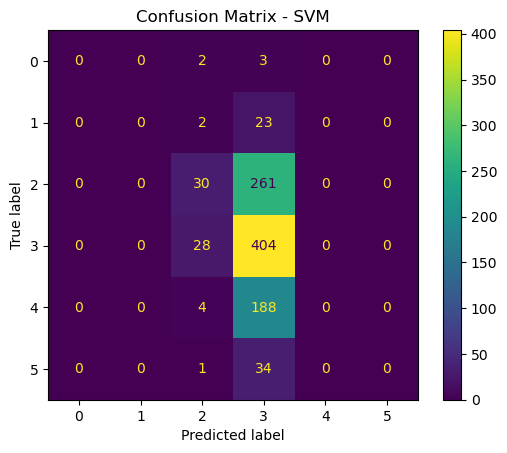

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00        25
           5       0.45      0.10      0.17       291
           6       0.44      0.94      0.60       432
           7       0.00      0.00      0.00       192
           8       0.00      0.00      0.00        35

    accuracy                           0.44       980
   macro avg       0.15      0.17      0.13       980
weighted avg       0.33      0.44      0.31       980



c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [84]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from matplotlib import pyplot as plt

# --- Khởi tạo mô hình ---
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1, gamma='scale')
cv = 5  # Số lượng folds

# --- Cross-validation ---
knn_cv_scores = cross_val_score(knn, X_train, y_train, cv=cv)
svm_cv_scores = cross_val_score(svm, X_train, y_train, cv=cv)
print(f"[CV] kNN Accuracy trung bình (cv={cv}): {knn_cv_scores.mean():.4f}")
print(f"[CV] SVM Accuracy trung bình (cv={cv}): {svm_cv_scores.mean():.4f}")

# --- Huấn luyện mô hình với toàn bộ tập train ---
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

# --- Dự đoán ---
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)

# --- Độ chính xác trên tập test ---
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"[Test] kNN Accuracy: {acc_knn:.4f}")
print(f"[Test] SVM Accuracy: {acc_svm:.4f}")

# --- Ma trận nhầm lẫn ---
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)

print("Confusion Matrix - kNN:")
disp_knn.plot()
plt.title("Confusion Matrix - kNN")
plt.show()
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix - SVM:")
disp_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()
print(classification_report(y_test, y_pred_svm))

In [85]:
7) Cài đặt thêm 2 thuật toán: Linear Discriminant Analysis (LDA) và Random Forest (RF). 

SyntaxError: unmatched ')' (1371216109.py, line 1)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

lda = LinearDiscriminantAnalysis()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# LDA
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda)

# RF
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

[Test] LDA Accuracy: 0.5122
confusion_matrix - LDA:


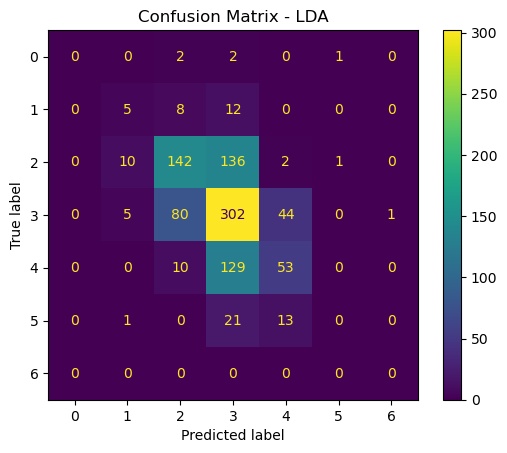

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.24      0.20      0.22        25
           5       0.59      0.49      0.53       291
           6       0.50      0.70      0.58       432
           7       0.47      0.28      0.35       192
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         0

    accuracy                           0.51       980
   macro avg       0.26      0.24      0.24       980
weighted avg       0.49      0.51      0.49       980



c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\minic

In [ ]:
print(f"[Test] LDA Accuracy: {acc_lda:.4f}")
print("confusion_matrix - LDA:")
disp_lda.plot()
plt.title("Confusion Matrix - LDA")
plt.show()
print(classification_report(y_test, y_pred_lda))

[Test] RF Accuracy: 0.6898
Confusion Matrix - Random Forest:


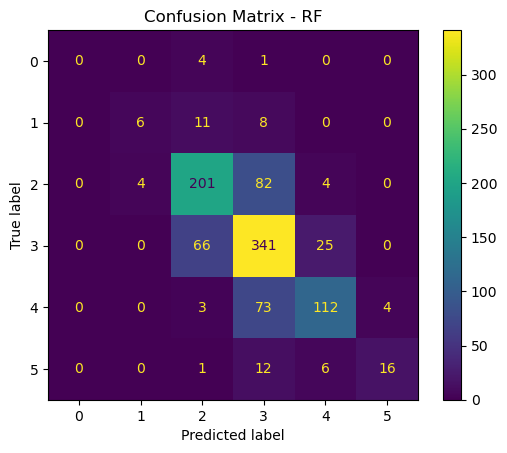

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.60      0.24      0.34        25
           5       0.70      0.69      0.70       291
           6       0.66      0.79      0.72       432
           7       0.76      0.58      0.66       192
           8       0.80      0.46      0.58        35

    accuracy                           0.69       980
   macro avg       0.59      0.46      0.50       980
weighted avg       0.69      0.69      0.68       980



c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Thy\miniconda3\envs\DS108\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(f"[Test] RF Accuracy: {acc_rf:.4f}")
print("Confusion Matrix - Random Forest:")
disp_rf.plot()
plt.title("Confusion Matrix - RF")
plt.show()
print(classification_report(y_test, y_pred_rf))

In [ ]:
import numpy as np

# Danh sách để lưu Accuracy
knn_accuracies = []
svm_accuracies = []
lda_accuracies = []
rf_accuracies = []

# Thực hiện 5 lần với các seed khác nhau
for seed in [42, 7, 123, 2023, 99]:
    # Bước 1-2: Chia dữ liệu (giữ nguyên X, y từ preprocessing trước đó)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Bước 3: Tạo mô hình
    knn = KNeighborsClassifier(n_neighbors=3)
    svm = SVC(kernel='linear')
    lda = LinearDiscriminantAnalysis()
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)

    # Bước 4: Huấn luyện mô hình
    knn.fit(X_train, y_train)
    svm.fit(X_train, y_train)
    lda.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    # Bước 5: Dự đoán
    y_pred_knn = knn.predict(X_test)
    y_pred_svm = svm.predict(X_test)
    y_pred_lda = lda.predict(X_test)
    y_pred_rf = rf.predict(X_test)

    # Bước 6: Accuracy
    acc_knn = accuracy_score(y_test, y_pred_knn)
    acc_svm = accuracy_score(y_test, y_pred_svm)
    acc_lda = accuracy_score(y_test, y_pred_lda)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    # Lưu lại kết quả
    knn_accuracies.append(acc_knn)
    svm_accuracies.append(acc_svm)
    lda_accuracies.append(acc_lda)
    rf_accuracies.append(acc_rf)

    # In kết quả từng lần
    print(f"Seed {seed} - kNN Accuracy: {acc_knn:.4f} | SVM Accuracy: {acc_svm:.4f} | LDA Accuracy: {acc_lda:.4f} | RF Accuracy: {acc_rf:.4f}")

# Bước 7: Tính độ chính xác trung bình
avg_knn = np.mean(knn_accuracies)
avg_svm = np.mean(svm_accuracies)
avg_lda = np.mean(lda_accuracies)
avg_rf = np.mean(rf_accuracies)

print("\n==============================")
print(f"Trung bình Accuracy kNN: {avg_knn:.4f}")
print(f"Trung bình Accuracy SVM: {avg_svm:.4f}")
print(f"Trung bình Accuracy LDA: {avg_lda:.4f}")
print(f"Trung bình Accuracy RF: {avg_rf:.4f}")
